importing dependencies

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics

data collection and preprocess

In [3]:
car_dataset=pd.read_csv('/content/CAR DETAILS FROM CAR DEKHO.csv')

In [5]:
car_dataset.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [8]:
car_dataset.shape

(4340, 8)

In [9]:
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [10]:
car_dataset.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


In [13]:
print(car_dataset.fuel.value_counts())
print(car_dataset.seller_type.value_counts())
print(car_dataset.transmission.value_counts())
print(car_dataset.owner.value_counts())

fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64
seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64
transmission
Manual       3892
Automatic     448
Name: count, dtype: int64
owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64


encoding categorial data

In [51]:
car_dataset.replace({'fuel':{'Petrol':0,'Diesel':1,'CNG':2,'LPG':3,'Electric':4}},inplace=True)
car_dataset.replace({'seller_type':{'Dealer':0,'Individual':1,'Trustmark Dealer':2}},inplace=True)
car_dataset.replace({'transmission':{'Manual':0,'Automatic':1}},inplace=True)

/tmp/ipykernel_2847/674937336.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'seller_type':{'Dealer':0,'Individual':1,'Trustmark Dealer':2}},inplace=True)


In [52]:
car_dataset.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,0,1,0,0
1,Maruti Wagon R LXI Minor,2007,135000,50000,0,1,0,0
2,Hyundai Verna 1.6 SX,2012,600000,100000,1,1,0,0
3,Datsun RediGO T Option,2017,250000,46000,0,1,0,0
4,Honda Amaze VX i-DTEC,2014,450000,141000,1,1,0,1


In [54]:
car_dataset.replace({'owner':{'First Owner':0,'Second Owner':1,'Third Owner':2,'Fourth & Above Owner':3,'Test Drive Car':4}},inplace=True)

In [55]:
car_dataset.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,0,1,0,0
1,Maruti Wagon R LXI Minor,2007,135000,50000,0,1,0,0
2,Hyundai Verna 1.6 SX,2012,600000,100000,1,1,0,0
3,Datsun RediGO T Option,2017,250000,46000,0,1,0,0
4,Honda Amaze VX i-DTEC,2014,450000,141000,1,1,0,1


spliting data and target

In [56]:
X =car_dataset.drop(['name','selling_price'],axis=1)
Y =car_dataset['selling_price']

In [57]:
print(X)

      year  km_driven  fuel  seller_type  transmission  owner
0     2007      70000     0            1             0      0
1     2007      50000     0            1             0      0
2     2012     100000     1            1             0      0
3     2017      46000     0            1             0      0
4     2014     141000     1            1             0      1
...    ...        ...   ...          ...           ...    ...
4335  2014      80000     1            1             0      1
4336  2014      80000     1            1             0      1
4337  2009      83000     0            1             0      1
4338  2016      90000     1            1             0      0
4339  2016      40000     0            1             0      0

[4340 rows x 6 columns]


In [58]:
print(Y)

0        60000
1       135000
2       600000
3       250000
4       450000
         ...  
4335    409999
4336    409999
4337    110000
4338    865000
4339    225000
Name: selling_price, Length: 4340, dtype: int64


spliting training and testing data

In [59]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2)

model training

linear regression model

In [62]:
lr = LinearRegression()

In [63]:
lr.fit(X_train,Y_train)

LinearRegression()

model evaluation

In [64]:
training_pred=lr.predict(X_train)

r squared error

In [65]:
error=metrics.r2_score(Y_train,training_pred)

In [66]:
print(error)

0.4267032363113096


visualise the actual price and predictions

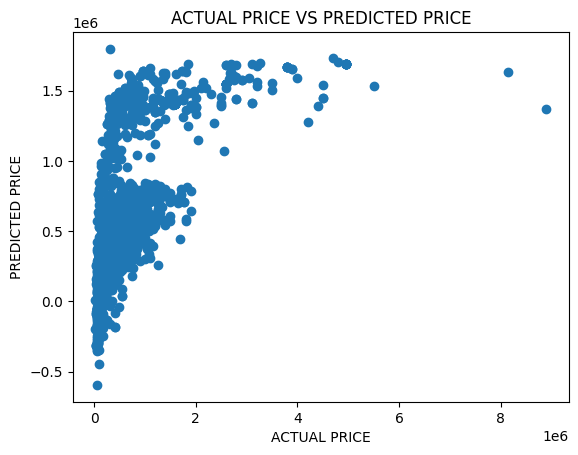

In [67]:
plt.scatter(Y_train,training_pred)
plt.xlabel("ACTUAL PRICE")
plt.ylabel("PREDICTED PRICE")
plt.title("ACTUAL PRICE VS PREDICTED PRICE")
plt.show()

testing data check

In [69]:
test_pred=lr.predict(X_test)

In [70]:
error1=metrics.r2_score(Y_test,test_pred)

In [71]:
print(error1)

0.46897548907629794


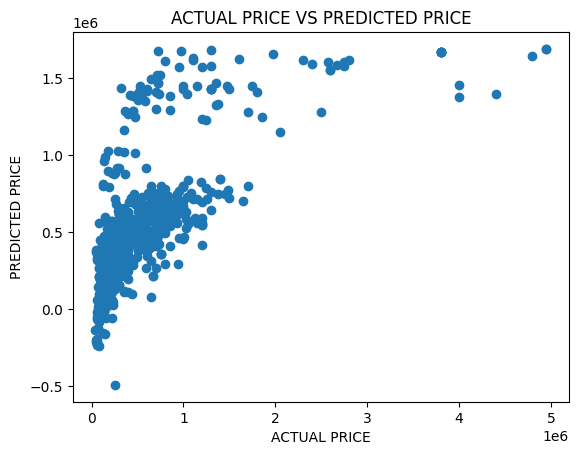

In [73]:
plt.scatter(Y_test,test_pred)
plt.xlabel("ACTUAL PRICE")
plt.ylabel("PREDICTED PRICE")
plt.title("ACTUAL PRICE VS PREDICTED PRICE")
plt.show()

lasso regression

In [74]:
lar=Lasso()

In [76]:
lar.fit(X_train,Y_train)

Lasso()

In [ ]:
model evaluation

In [81]:
training_data_pred=lar.predict(X_train)

In [86]:
error2=metrics.r2_score(Y_train,training_data_pred)

In [87]:
print(error2)

0.42670323625744433


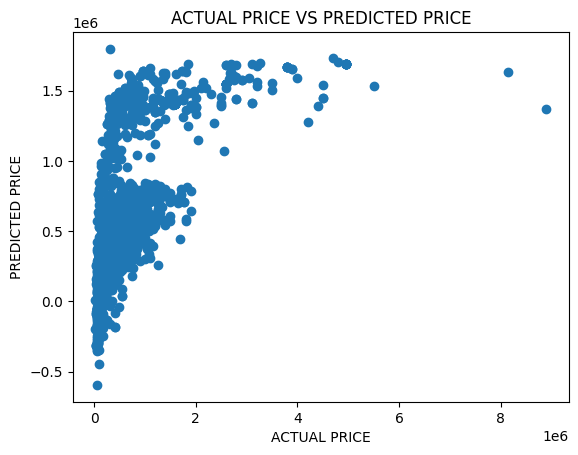

In [88]:
plt.scatter(Y_train,training_data_pred)
plt.xlabel("ACTUAL PRICE")
plt.ylabel("PREDICTED PRICE")
plt.title("ACTUAL PRICE VS PREDICTED PRICE")
plt.show()

In [85]:
testing_data_pred=lar.predict(X_test)

In [90]:
error3=metrics.r2_score(Y_test,testing_data_pred)

In [91]:
print(error3)

0.46897506154011537


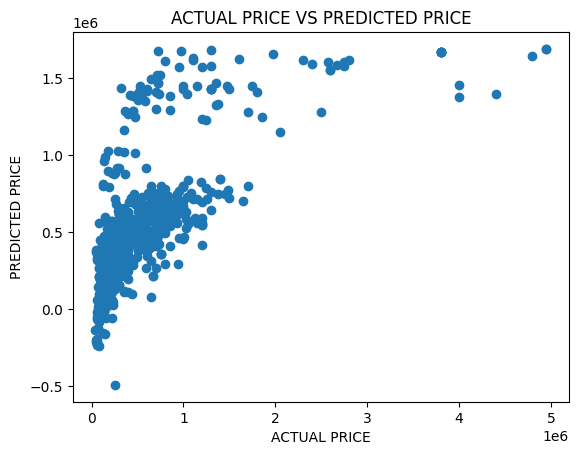

In [92]:
plt.scatter(Y_test,testing_data_pred)
plt.xlabel("ACTUAL PRICE")
plt.ylabel("PREDICTED PRICE")
plt.title("ACTUAL PRICE VS PREDICTED PRICE")
plt.show()